# 01_Preprocessing_Pipeline.ipynb - tiền xử lý ảnh
**Mục tiêu:** Trình diễn từng bước biến đổi trạng thái ảnh từ lúc đầy nhiễu đến khi "sạch sẽ".

## 1. Nạp ảnh gốc & Áp dụng Circular Mask (Cắt góc đen)

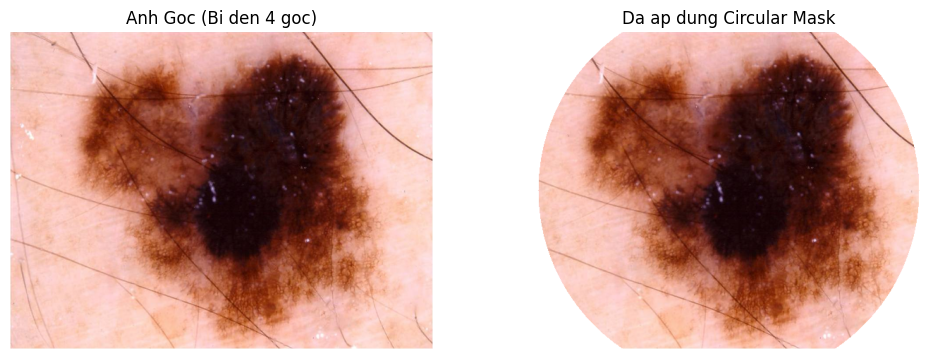

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Đảm bảo Kernel nhận diện được thư mục src
sys.path.append(r'd:\Computer Vision Final Project\Src code')

from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe

# Đặt đường dẫn tuyệt đối cho an toàn
img_path = r'd:\Computer Vision Final Project\Src code\data\toy_data\melanoma\ISIC_0000161.jpg'
img = cv2.imread(img_path)
img = cv2.resize(img, (600, 450))

# Áp dụng Circular Mask để xóa viền đen ống kính
img_no_corners = apply_circular_mask(img, radius_reduction=1.2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title("Anh Goc (Bi den 4 goc)")
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_no_corners, cv2.COLOR_BGR2RGB))
axs[1].set_title("Da ap dung Circular Mask")
axs[1].axis('off')
plt.show()

## 2. Khảo sát DullRazor (Xóa lông)

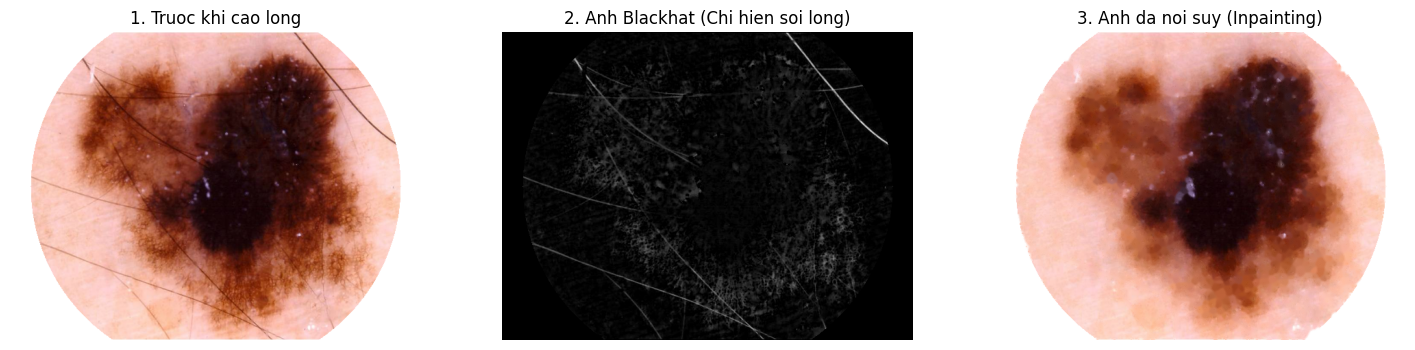

In [36]:
# Chạy DullRazor (Trong source trả về ảnh sạch và mask lông)
clean_img, hair_mask = remove_hair(img_no_corners, kernel_size=15, inpaint_rad=3)

# Tự chạy lại Blackhat để trực quan hóa rõ sợi lông (Do hàm gốc không return blackhat)
gray = cv2.cvtColor(img_no_corners, cv2.COLOR_BGR2GRAY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(cv2.cvtColor(img_no_corners, cv2.COLOR_BGR2RGB))
axs[0].set_title("1. Truoc khi cao long")
axs[0].axis('off')

axs[1].imshow(blackhat, cmap='gray')
axs[1].set_title("2. Anh Blackhat (Chi hien soi long)")
axs[1].axis('off')

axs[2].imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))
axs[2].set_title("3. Anh da noi suy (Inpainting)")
axs[2].axis('off')
plt.show()

## 3. Khảo sát Ánh sáng (CLAHE)

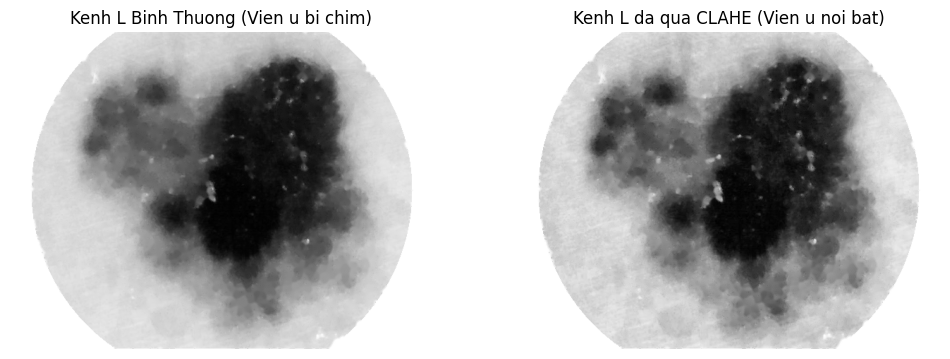

In [37]:
# Tách kênh L bình thường (Chưa qua CLAHE)
lab_image = cv2.cvtColor(clean_img, cv2.COLOR_BGR2LAB)
l_normal, _, _ = cv2.split(lab_image)

# Chạy CLAHE
clahe_color_img, l_clahe = enhance_contrast_clahe(clean_img, clip_limit=1.1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(l_normal, cmap='gray')
axs[0].set_title("Kenh L Binh Thuong (Vien u bi chim)")
axs[0].axis('off')

axs[1].imshow(l_clahe, cmap='gray')
axs[1].set_title("Kenh L da qua CLAHE (Vien u noi bat)")
axs[1].axis('off')
plt.show()

## 4. Khảo sát Khử nhiễu (Gaussian Blur)

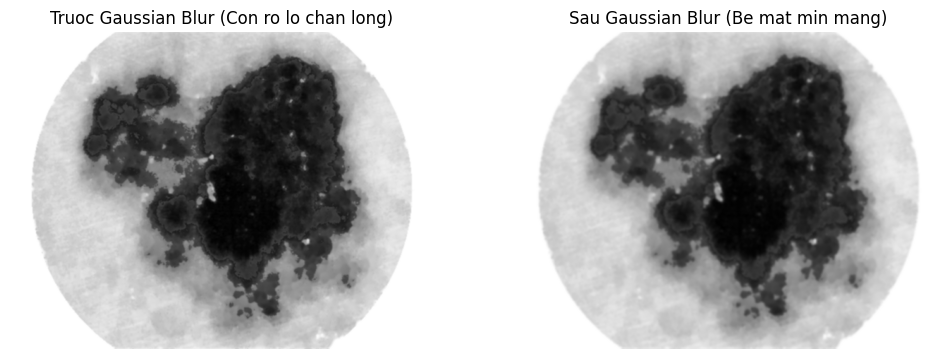

In [38]:
from src.preprocessing import boost_faint_edges

# Boost nhẹ viền mờ trước khi làm mượt (theo luồng pipeline gốc)
boosted_l, _ = boost_faint_edges(l_clahe)

# Khử nhiễu bằng Gaussian Blur
smooth_l = cv2.GaussianBlur(boosted_l, (5, 5), 0)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(boosted_l, cmap='gray')
axs[0].set_title("Truoc Gaussian Blur (Con ro lo chan long)")
axs[0].axis('off')

axs[1].imshow(smooth_l, cmap='gray')
axs[1].set_title("Sau Gaussian Blur (Be mat min mang)")
axs[1].axis('off')
plt.show()